# Dataset Inspection — BraTS 2021

## 1. Import Libraries

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

## 2. Dataset Path

In [2]:
REPO_ROOT    = Path().resolve().parent
DATASET_ROOT = REPO_ROOT / 'data' / 'raw' / 'BraTS2021' / 'BraTS2021_Training_Data'

print(f'Repo root    : {REPO_ROOT}')
print(f'Dataset root : {DATASET_ROOT}')
print(f'Exists       : {DATASET_ROOT.exists()}')

Repo root    : C:\3D-Glioblastoma-MRI
Dataset root : C:\3D-Glioblastoma-MRI\data\raw\BraTS2021\BraTS2021_Training_Data
Exists       : True


## 3. Patient Folders

In [3]:
cases = sorted([p for p in DATASET_ROOT.iterdir() if p.is_dir()])

print(f'Total cases : {len(cases)}')
print(f'First 5     : {[c.name for c in cases[:5]]}')
print(f'Last 5      : {[c.name for c in cases[-5:]]}')

Total cases : 1251
First 5     : ['BraTS2021_00000', 'BraTS2021_00002', 'BraTS2021_00003', 'BraTS2021_00005', 'BraTS2021_00006']
Last 5      : ['BraTS2021_01662', 'BraTS2021_01663', 'BraTS2021_01664', 'BraTS2021_01665', 'BraTS2021_01666']


## 4. MRI Files in One Sample Case

In [4]:
sample_case = cases[0]
files = sorted(f.name for f in sample_case.iterdir() if f.is_file())

print(f'Case : {sample_case.name}')
for f in files:
    print(f'  {f}')

Case : BraTS2021_00000
  BraTS2021_00000_flair.nii.gz
  BraTS2021_00000_seg.nii.gz
  BraTS2021_00000_t1.nii.gz
  BraTS2021_00000_t1ce.nii.gz
  BraTS2021_00000_t2.nii.gz


## 5. Modality Completeness

In [5]:
SUFFIXES = {'t1': '_t1.nii.gz', 't1ce': '_t1ce.nii.gz',
            't2': '_t2.nii.gz', 'flair': '_flair.nii.gz', 'seg': '_seg.nii.gz'}

rows = []
for case in cases:
    files_present = {f.name for f in case.iterdir() if f.is_file()}
    rows.append({mod: (case.name + suffix) in files_present
                 for mod, suffix in SUFFIXES.items()})

df = pd.DataFrame(rows)
df.sum().rename('cases with file').to_frame()

,cases with file
t1,1251
t1ce,1251
t2,1251
flair,1251
seg,1251


In [6]:
# Cases missing at least one expected file
incomplete = df[~df.all(axis=1)]
print(f'Incomplete cases: {len(incomplete)}')

Incomplete cases: 0


## 6. Load One Patient

In [7]:
# Pick the first fully complete case
complete_ids = [c for (c, ok) in zip(cases, df.all(axis=1)) if ok]
case         = complete_ids[0]
case_id      = case.name

print(f'Loading case: {case_id}')

imgs = {mod: nib.load(str(case / (case_id + suffix)))
        for mod, suffix in SUFFIXES.items() if mod != 'seg'}

Loading case: BraTS2021_00000


## 7. MRI Volume Properties

In [8]:
records = []
for mod, img in imgs.items():
    hdr = img.header
    records.append({
        'modality'     : mod,
        'shape'        : img.shape,
        'dtype'        : str(img.get_data_dtype()),
        'voxel_mm'     : tuple(round(float(v), 2) for v in hdr.get_zooms()),
    })

pd.DataFrame(records)

,modality,shape,dtype,voxel_mm
0,t1,"(240, 240, 155)",int16,"(1.0, 1.0, 1.0)"
1,t1ce,"(240, 240, 155)",int16,"(1.0, 1.0, 1.0)"
2,t2,"(240, 240, 155)",int16,"(1.0, 1.0, 1.0)"
3,flair,"(240, 240, 155)",int16,"(1.0, 1.0, 1.0)"


## 8. Segmentation

In [9]:
seg_img  = nib.load(str(case / (case_id + '_seg.nii.gz')))
seg_data = np.asarray(seg_img.dataobj, dtype=np.int16)

ref_shape = list(imgs.values())[0].shape

print(f'Shape         : {seg_data.shape}')
print(f'Dtype         : {seg_img.get_data_dtype()}')
print(f'Unique labels : {np.unique(seg_data).tolist()}')
print(f'Shape matches MRI: {seg_data.shape == ref_shape}')

Shape         : (240, 240, 155)
Dtype         : uint8
Unique labels : [0, 1, 2, 4]
Shape matches MRI: True


## 9. Visualization — MRI Slices

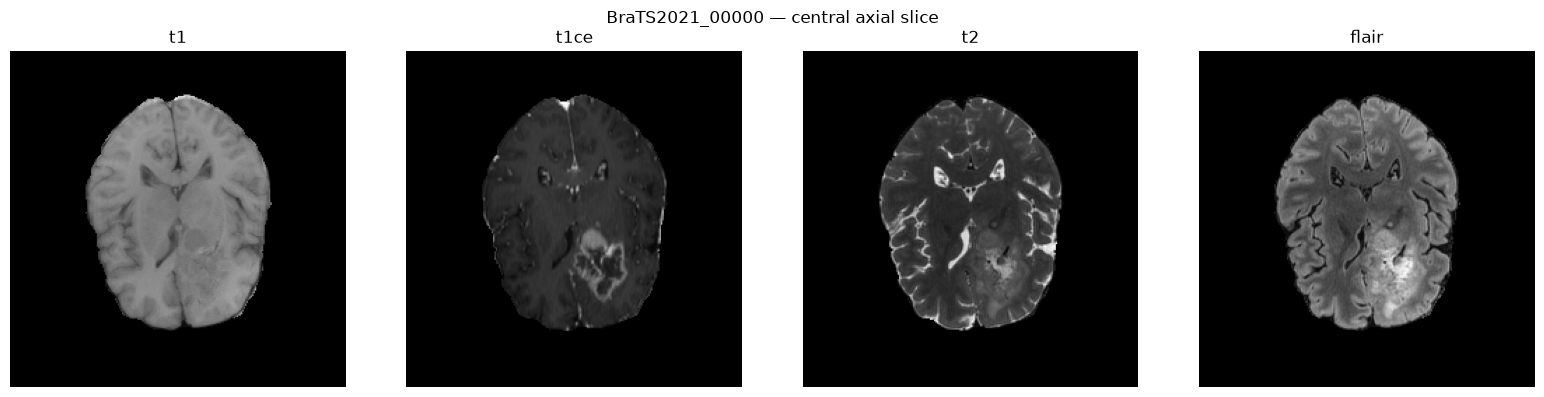

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(f'{case_id} — central axial slice', fontsize=12)

for ax, (mod, img) in zip(axes, imgs.items()):
    data = img.get_fdata()
    z    = data.shape[2] // 2
    ax.imshow(data[:, :, z].T, origin='lower', cmap='gray')
    ax.set_title(mod)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 10. Visualization — Segmentation

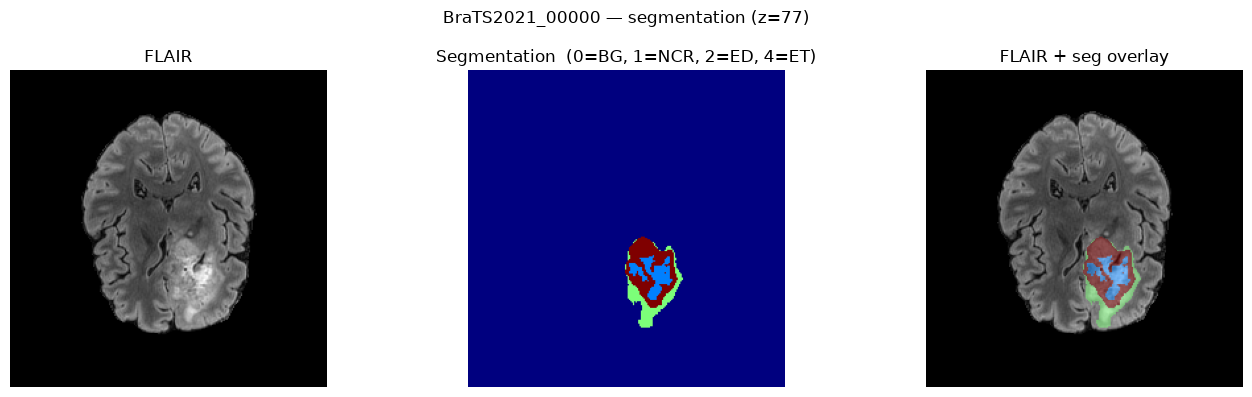

In [11]:
flair = list(imgs.values())[3].get_fdata()  # FLAIR is last in SUFFIXES order
z     = seg_data.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'{case_id} — segmentation (z={z})', fontsize=12)

axes[0].imshow(flair[:, :, z].T,    origin='lower', cmap='gray')
axes[0].set_title('FLAIR')

axes[1].imshow(seg_data[:, :, z].T, origin='lower', cmap='jet', vmin=0, vmax=4)
axes[1].set_title('Segmentation  (0=BG, 1=NCR, 2=ED, 4=ET)')

axes[2].imshow(flair[:, :, z].T,    origin='lower', cmap='gray')
mask = np.ma.masked_where(seg_data[:, :, z] == 0, seg_data[:, :, z])
axes[2].imshow(mask.T,              origin='lower', cmap='jet', alpha=0.5, vmin=0, vmax=4)
axes[2].set_title('FLAIR + seg overlay')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()